# Esperimenti tesi

Il primo esperimento che voglio fare è fittare una serie di alberi con diverse profondità su dei dati sintetici $y \in \{1,-1\}$ e verificare se la differenza tra l'errore su un training set ($\hat R$) e l'errore su un test set ($R$) segue l'andamento previsto dal bound Prop 2.2, cioè aumenta all'aumentare della profondità del mio albero. 

N.B. parlo di profondità perché nel caso degli alberi, la cardinalità dell'insieme di ipotesi $\mathcal{H}$ è proporzionale alla profondità, in altre parole più profondo l'albero più comlpesso il modello che impariamo. 

## dati


Costruiamo un dataset sintetico di size $n$, secondo la legge 
\begin{gather}
x \sim \mathrm{Unif}(\text{supp}(0,10))\\
y \coloneqq \mathrm{sign}(f(x) + \varepsilon), \quad \varepsilon \sim \mathcal{N}(0,1)
\end{gather}
for some $f: X \to Y$ convex and where supp(0,10) is a discretization of the interval $[0,10]$. 


In [249]:
print('mare')

mare


In [250]:
# build dataset

import numpy as np

rng = np.random.default_rng(seed=4)  

N = 10_000

def sample_x(n, l=0.0, u=10.0, rng=rng, supp_size=N):
    """sample n points from supp evenly spaced points on [l, u]"""
    support = np.linspace(l, u, supp_size)
    return rng.choice(support, size=n, replace=True)

def sample_y(x, f, sigma=1.0, rng=rng):
    """y = sign(f(x) + e), e ~ N(0, sigma)"""
    e = sigma * rng.standard_normal(size=len(x))
    return np.sign(f(x) + e)

def sample_y_bernoulli(x, f, p=0.8, rng=rng):
    """y = sign(f(x)) * b, b = +1 w.p. p, b = -1 w.p. 1-p"""
    b = rng.choice(np.array([1, -1]), size=len(x), p=[p, 1 - p])
    return np.sign(f(x)) * b

Notation:

- $n$ is the number of training samples
- $n_\text{test}$ is the number of test samples
- $N$ is the size of the support of the x

and we want $n << N << n_\text{test} \approx \infty$. 

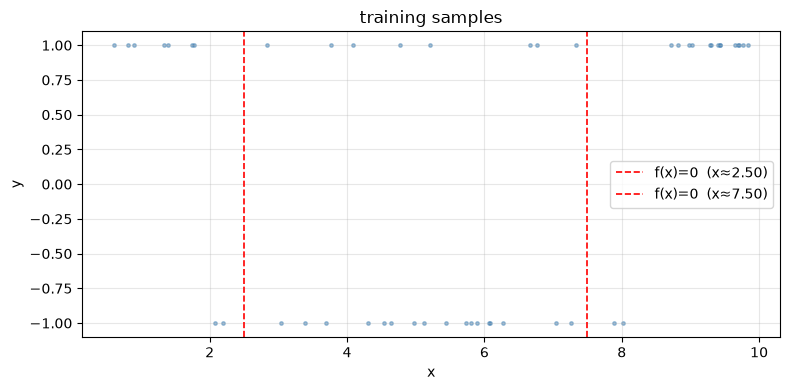

In [251]:
# generate dataset

n = 50
noise_std = 5
noise_p = 0.8
# n<200, 10,20,50        
# n_test > N
def f(x):
    return (x-5)**2 - 6.25  # change here to change function (convex)   
# dal ragionamento con integrale si possono usare circa c = 12 e d = 7 dove f(x) = (x-c)**2 - d        

x = sample_x(n)
y = sample_y(x, f, sigma = noise_std)
# y = sample_y_bernoulli(x, f, p = noise_p)

# generate test

n_test = 200000

x_test = sample_x(n_test)
y_test = sample_y(x_test, f, sigma = noise_std)
# y_test = sample_y_bernoulli(x_test, f, p = noise_p)


# inspect data

from scipy.optimize import brentq
import matplotlib.pyplot as plt

# hardcoded zeros
x0=2.5
x1=7.5

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, s=6, alpha=0.5, color="steelblue")
ax.axvline(x=x0, color="red", linestyle="--", linewidth=1.2, label=f"f(x)=0  (x≈{x0:.2f})")
ax.axvline(x=x1, color="red", linestyle="--", linewidth=1.2, label=f"f(x)=0  (x≈{x1:.2f})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("training samples")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Rk: 

With ```noise_coeff``` $=1$, only with $n=50$ (not $10, 20$) I get some misclassified inputs. 

For ```noise_coeff```$=2$ and $n=20$ I get ~1 misclassified input. Enough?


## alberi


In [252]:
from sklearn.tree import DecisionTreeClassifier

threshold = np.log2(n)  # interpolation threshold
threshold_int = int(np.floor(threshold))

# every integer from 1 to floor(threshold) inclusive, then up to floor(2*threshold)
depths_int = np.arange(1, int(np.floor(4 * threshold)) + 1)
depths_float = depths_int.astype(float)

# reshape
x = x.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

trees, train_errors, test_errors = [], [], []

for d in depths_int:
    clf = DecisionTreeClassifier(max_depth=int(d), random_state=42)
    clf.fit(x, y)
    train_errors.append(1 - clf.score(x, y))
    test_errors.append(1 - clf.score(x_test, y_test))
    trees.append(clf)

print(f"threshold = log2({n}) = {threshold:.3f}  →  floor = {threshold_int}")
print(f"depths: {list(depths_int)}")


threshold = log2(50) = 5.644  →  floor = 5
depths: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]


## plot


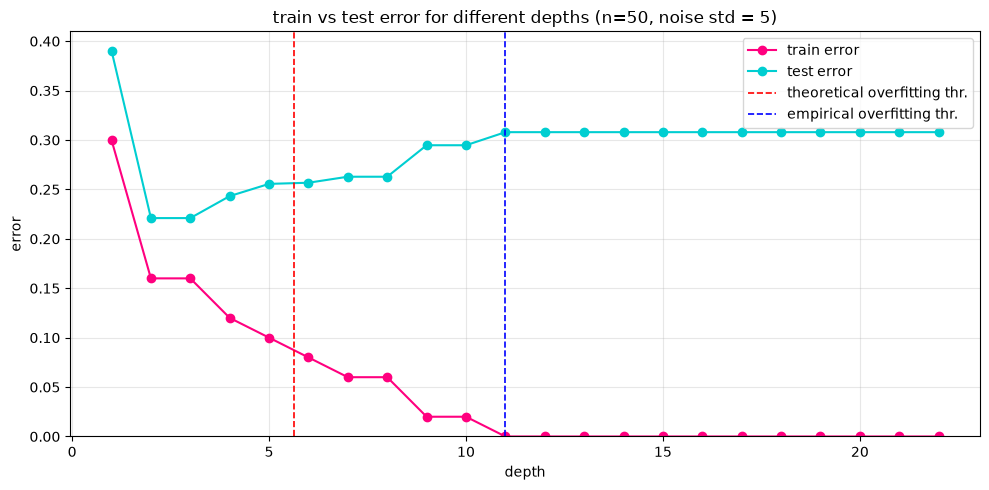

In [253]:
import matplotlib.pyplot as plt

# first depth where train error hits 0
zero_train = next((d for d, e in zip(depths_float, train_errors) if e == 0), None)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(depths_float, train_errors, color="#FF007F", marker="o", label="train error")
ax.plot(depths_float, test_errors,  color="#00CED1", marker="o", label="test error")

ax.axvline(threshold, color="red", linestyle="--", linewidth=1.2, label="theoretical overfitting thr.")
if zero_train is not None:
    ax.axvline(zero_train, color="blue", linestyle="--", linewidth=1.2, label="empirical overfitting thr.")

ax.set_xlabel("depth")
ax.set_ylabel("error")
ax.set_ylim(bottom=0)
ax.set_title(f"train vs test error for different depths (n={n}, noise std = {noise_std})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Commenti:

Se ho 20 punti di training, arrivo a 0 alla depth prevista teoricamente (con noise std = 5). Con 50, 100 punti training arrivo molto dopo. 
Con 100 punti training e noise std = 2, ci arrivo prima. 

Noise std = 5 e n = 50 è quello che mi piace di più perché si vede bene un gap che aumenta all'aumentare della depth. 

Aumentando la varianza (sia con noise_std sia con data size), c'è bisogno di ispezionare più depths per vedere il trend nel lungo termine. 


Although the theoretical overfitting threshold does not always correspond to the empirical one due to noise (the red and blue line don't coincide), the depth at which the training error is 0 is always the one at wihch the test error becomes constant. This is theoretically justified because once I leanr everything I can from the training data, the model on unseen data cannot do any better!


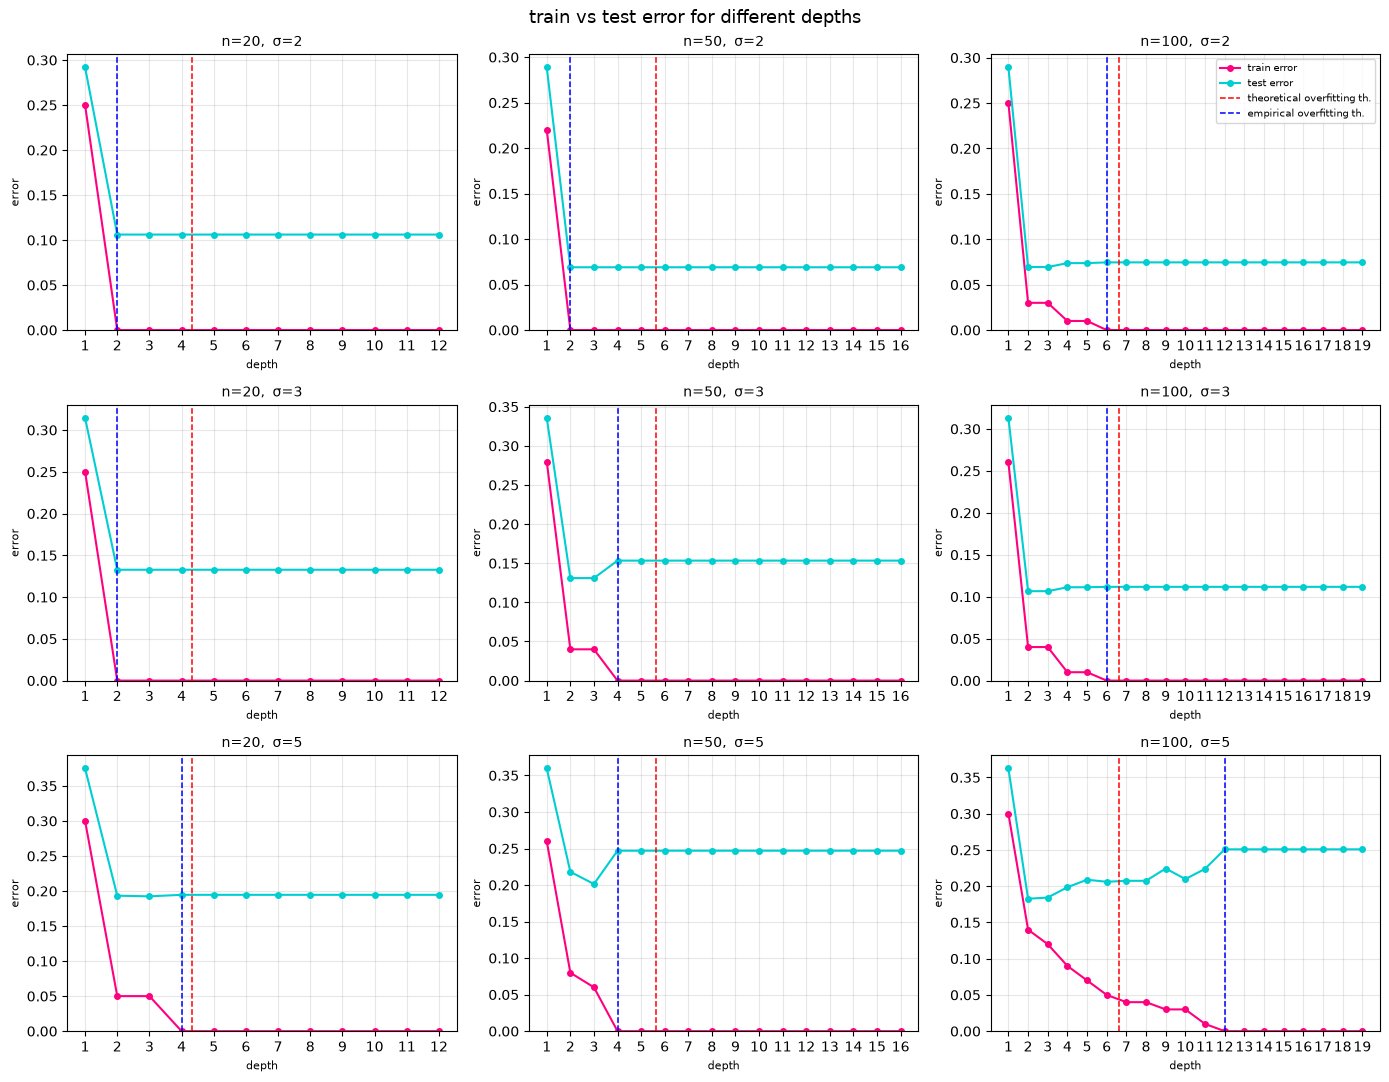

In [254]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

n_values     = [ 20, 50, 100]
sigma_values = [ 2, 3, 5]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for row, sigma in enumerate(sigma_values):
    for col, n_val in enumerate(n_values):
        ax = axes[row, col]
        rng_loc = np.random.default_rng(seed=42)

        x_tr = sample_x(n_val, rng=rng_loc)
        y_tr = sample_y(x_tr, f, sigma=sigma, rng=rng_loc)
        x_te = sample_x(200_000, rng=rng_loc)
        y_te = sample_y(x_te, f, sigma=sigma, rng=rng_loc)

        threshold = np.log2(n_val)
        depths = np.arange(1, int(np.floor(3 * threshold)) + 1)

        train_err, test_err = [], []
        for d in depths:
            clf = DecisionTreeClassifier(max_depth=int(d), random_state=42)
            clf.fit(x_tr.reshape(-1, 1), y_tr)
            train_err.append(1 - clf.score(x_tr.reshape(-1, 1), y_tr))
            test_err.append(1 - clf.score(x_te.reshape(-1, 1), y_te))

        zero_depth = next((d for d, e in zip(depths, train_err) if e == 0), None)

        ax.plot(depths, train_err, color="#FF007F", marker="o", markersize=4, label="train error")
        ax.plot(depths, test_err,  color="#00CED1", marker="o", markersize=4, label="test error")
        ax.axvline(threshold,  color="red",  linestyle="--", linewidth=1.1, label="theoretical overfitting th.")
        if zero_depth is not None:
            ax.axvline(zero_depth, color="blue", linestyle="--", linewidth=1.1, label="empirical overfitting th.")

        ax.set_ylim(bottom=0)
        ax.set_title(f"n={n_val},  σ={sigma}", fontsize=10)
        # ax.set_title(f"n={n_val},  p={noise_p}", fontsize=10)
        ax.set_xlabel("depth", fontsize=8)
        ax.set_ylabel("error", fontsize=8)
        ax.set_xticks(depths)
        ax.grid(True, alpha=0.3)

        if row == 0 and col == 2:
            ax.legend(fontsize=7, loc="upper right")

plt.suptitle("train vs test error for different depths", fontsize=13)
plt.tight_layout()
plt.show()
